# Explore real Mars terrain data

Reads the same source rasters `prep_site.sh` uses, streamed via GDAL's `/vsicurl/` (HTTP range reads — nothing downloaded in full). Query, plot, histogram, and cross-check against the game's baked `elevMin`/`elevMax` in `js/sites.js`.

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

S3 = "https://asc-pds-services.s3.us-west-2.amazonaws.com"

SOURCES = {
    "jezero_dem": f"/vsicurl/{S3}/mosaic/mars2020_trn/CTX/JEZ_ctx_B_soc_008_DTM_MOLAtopography_DeltaGeoid_20m_Eqc_latTs0_lon0.tif",
    "jezero_ortho": f"/vsicurl/{S3}/mosaic/mars2020_trn/CTX/JEZ_ctx_B_soc_008_orthoMosaic_6m_Eqc_latTs0_lon0.tif",
    "gale_dem": f"/vsicurl/{S3}/mosaic/Mars/MSL/MSL_Gale_DEM_Mosaic_1m_v3.tif",
    "gale_ortho": f"/vsicurl/{S3}/mosaic/Mars/MSL/MSL_Gale_HiRISE-LRGB_78quads_sharp_cog.tif",
}

# AOI crops used by prep_site.sh (native SRS meters): (ulx, uly, lrx, lry)
AOI = {
    "jezero": (4585750.7, 1096914.5, 4591750.7, 1090914.5),
    "gale":   (8140000,   -271500,   8149000,   -280500),
}

Matplotlib is building the font cache; this may take a moment.


## 1. Open a raster and inspect metadata (no download — lazy handle only)

In [2]:
ds = rasterio.open(SOURCES["jezero_dem"])
print("CRS:", ds.crs)
print("Size (w,h):", ds.width, ds.height)
print("Res (m/px):", ds.res)
print("Bounds:", ds.bounds)
print("Dtype:", ds.dtypes)
print("NoData:", ds.nodata)

CRS: ESRI:103885
Size (w,h): 1596 1512
Res (m/px): (20.0, 20.0)
Bounds: BoundingBox(left=4573663.250853, bottom=1079453.140188, right=4605583.250853, top=1109693.140188)
Dtype: ('float32',)
NoData: -3.4028226550889045e+38


## 2. Windowed read — only the crop the game actually uses (streams just this AOI)

In [3]:
from rasterio.windows import from_bounds

ulx, uly, lrx, lry = AOI["jezero"]
window = from_bounds(ulx, lry, lrx, uly, transform=ds.transform)  # rasterio wants (left, bottom, right, top)
crop = ds.read(1, window=window)
print("Crop shape:", crop.shape)
print("Crop min/max/mean:", np.nanmin(crop), np.nanmax(crop), np.nanmean(crop))

Crop shape: (300, 300)
Crop min/max/mean: -2595.9272 -2396.2993 -2517.467


/tmp/ipykernel_1330582/3056059056.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  crop = ds.read(1, window=window)


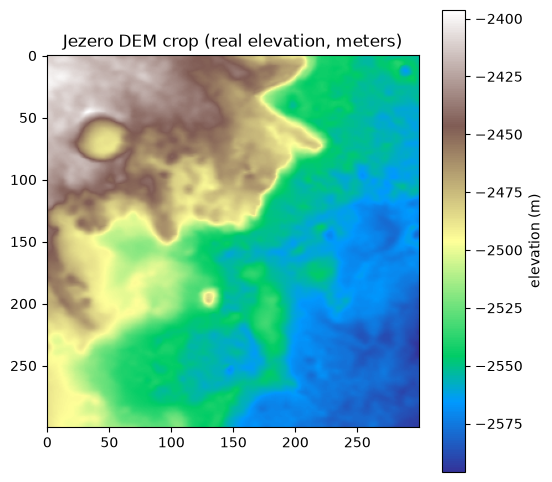

In [4]:
plt.figure(figsize=(6,6))
plt.imshow(crop, cmap="terrain")
plt.colorbar(label="elevation (m)")
plt.title("Jezero DEM crop (real elevation, meters)")
plt.show()

## 3. Point query — exact elevation at a real coordinate (e.g. landing site)

In [5]:
# Octavia E. Butler Landing, native SRS coords (see prep_site.sh comments)
x, y = 4588750.7 + 2127, 1093914.5 + 615  # crop center + spawn offset from sites.js
row, col = ds.index(x, y)
val = ds.read(1, window=((row, row+1), (col, col+1)))
print(f"Elevation at landing site: {val[0,0]:.2f} m")

Elevation at landing site: -2567.41 m


/tmp/ipykernel_1330582/1921739029.py:4: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  val = ds.read(1, window=((row, row+1), (col, col+1)))


## 4. Histogram — see the real distribution before it gets 8-bit quantized

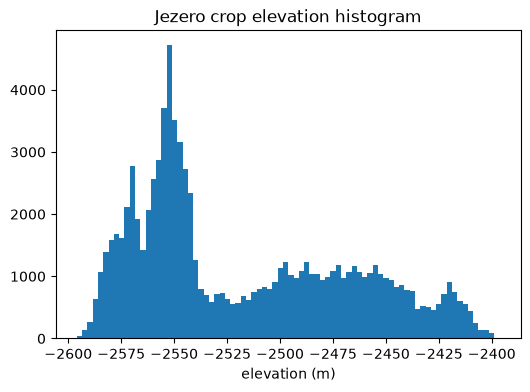

sites.js range: -2596.48 .. -2396.38  (span 200.10 m)
actual crop range: -2595.93 .. -2396.30
8-bit quantization step: 0.785 m/level


In [6]:
plt.figure(figsize=(6,4))
plt.hist(crop.flatten(), bins=80)
plt.xlabel("elevation (m)")
plt.title("Jezero crop elevation histogram")
plt.show()

# Compare against sites.js baked values
elevMin, elevMax = -2596.4763183594, -2396.3757324219
print(f"sites.js range: {elevMin:.2f} .. {elevMax:.2f}  (span {elevMax-elevMin:.2f} m)")
print(f"actual crop range: {crop.min():.2f} .. {crop.max():.2f}")
print(f"8-bit quantization step: {(elevMax-elevMin)/255:.3f} m/level")

## 5. Compare against the game's local 8-bit heightmap.png (quantization loss)

game heightmap.png shape: (1024, 1024)
decoded elev range: -2596.4763183594 -2396.3757324219


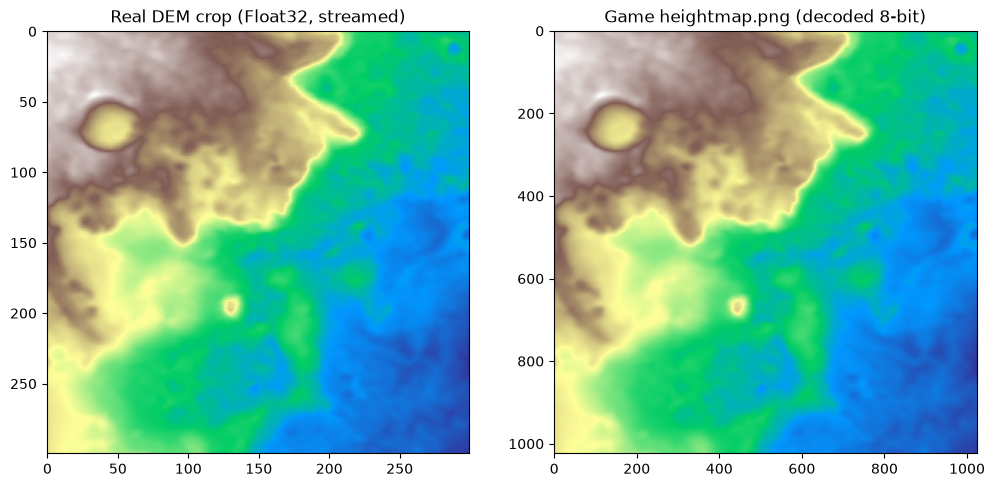

In [7]:
from PIL import Image

game_png = np.array(Image.open("../../public/mars-colony/assets/jezero/heightmap.png"))
game_elev = elevMin + (game_png.astype(float) / 255) * (elevMax - elevMin)

print("game heightmap.png shape:", game_png.shape)
print("decoded elev range:", game_elev.min(), game_elev.max())

fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(crop, cmap="terrain")
axes[0].set_title("Real DEM crop (Float32, streamed)")
axes[1].imshow(game_elev, cmap="terrain")
axes[1].set_title("Game heightmap.png (decoded 8-bit)")
plt.show()

## 6. Ortho imagery — real RGB, native resolution
Gale ortho is 25cm/px — cropping even a small window shows far more detail than the game's downsampled 2048px JPEG.

Gale ortho res (m/px): (0.25, 0.25) bands: 3


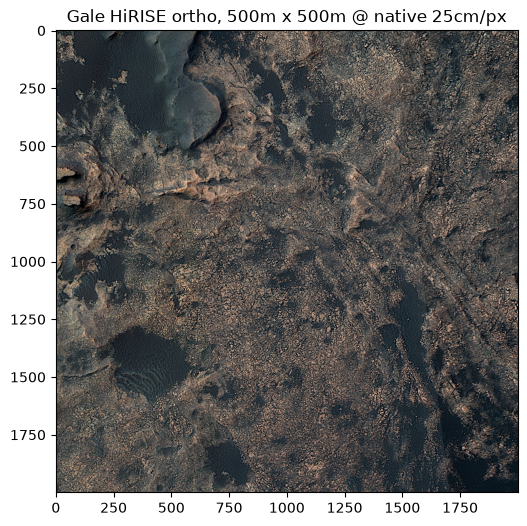

In [8]:
ortho_ds = rasterio.open(SOURCES["gale_ortho"])
print("Gale ortho res (m/px):", ortho_ds.res, "bands:", ortho_ds.count)

ulx, uly, lrx, lry = AOI["gale"]
# small 500m x 500m sub-window near Yellowknife Bay for a fast, detailed look
sub = from_bounds(ulx+2000, lry+2000, ulx+2500, lry+2500, transform=ortho_ds.transform)
rgb = ortho_ds.read([1,2,3], window=sub)
rgb = np.transpose(rgb, (1,2,0))

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("Gale HiRISE ortho, 500m x 500m @ native 25cm/px")
plt.show()